## Scheduler

In [ ]:
train_loader_rgb_2, val_loader_rgb_2, test_loader_rgb_2, kaggle_loader_rgb_2 = get_seg_dataloaders(
    "data/train",
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, seed=SEED, rgb=True,
    train_transform_img=base_img_tf,
    train_transform_mask=base_mask_tf,
    val_transform_img=base_img_tf,
    val_transform_mask=base_mask_tf
)

unet_rgb_22 = UNet(n_class=1, n_channels=3, padding=1, use_bn=True, dropout=0.3).to(DEVICE)
criterion_rgb_22 = combined_loss


optimizer = torch.optim.Adam(unet_rgb_22.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=4
)


model, optimizer, checkpoint = restaurar_modelo(unet_rgb_22, optimizer, "models/unet_rgb_2.pth", DEVICE)

epoch_train_errors_rgb_22, epoch_val_errors_rgb_22 = train(
    unet_rgb_22, optimizer, criterion_rgb_22, train_loader_rgb_2, val_loader_rgb_2, DEVICE, scheduler=scheduler,
    do_early_stopping=False, patience=10, epochs=100, log_every=5
)

Epoch: 002 | Train Loss: 0.16163 | Val Loss: 0.15514 | Current LR: 0.00010
Epoch: 005 | Train Loss: 0.15559 | Val Loss: 0.15357 | Current LR: 0.00010
Epoch: 010 | Train Loss: 0.14892 | Val Loss: 0.15636 | Current LR: 0.00005
Epoch: 015 | Train Loss: 0.13419 | Val Loss: 0.14641 | Current LR: 0.00005
Epoch: 020 | Train Loss: 0.13025 | Val Loss: 0.14468 | Current LR: 0.00005
Epoch: 025 | Train Loss: 0.11720 | Val Loss: 0.14445 | Current LR: 0.00003
Epoch: 030 | Train Loss: 0.11290 | Val Loss: 0.13949 | Current LR: 0.00001
Epoch: 035 | Train Loss: 0.10965 | Val Loss: 0.14255 | Current LR: 0.00001
Epoch: 040 | Train Loss: 0.11067 | Val Loss: 0.14382 | Current LR: 0.00000
Epoch: 045 | Train Loss: 0.10791 | Val Loss: 0.14116 | Current LR: 0.00000
Epoch: 050 | Train Loss: 0.10658 | Val Loss: 0.14090 | Current LR: 0.00000
Epoch: 055 | Train Loss: 0.10575 | Val Loss: 0.14191 | Current LR: 0.00000
Epoch: 060 | Train Loss: 0.10681 | Val Loss: 0.14125 | Current LR: 0.00000
Epoch: 065 | Train Loss: 

Accuracy: 0.9364
Dice: 0.8995


Reporte de clasificación:

              precision      recall      f1-score     support        dice    
no-persona       0.97         0.92         0.95       8531764.0              
persona          0.89         0.95         0.92       5492940.0              
accuracy                                   0.94                              
macro avg        0.93         0.94         0.93      14024704.0       0.9    
weighted avg     0.94         0.94         0.94      14024704.0       0.9    
1                                                                     0.9    



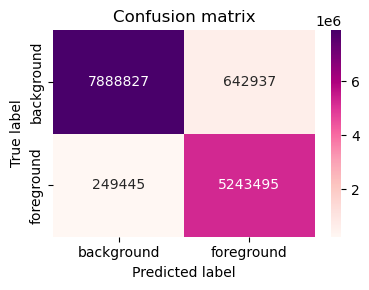

In [ ]:
acc, rep, cm = model_segmentation_report(
    unet_rgb_22, test_loader_rgb_2, DEVICE, NUM_CLASES, do_confusion_matrix=True, show_dice_loss=True
)

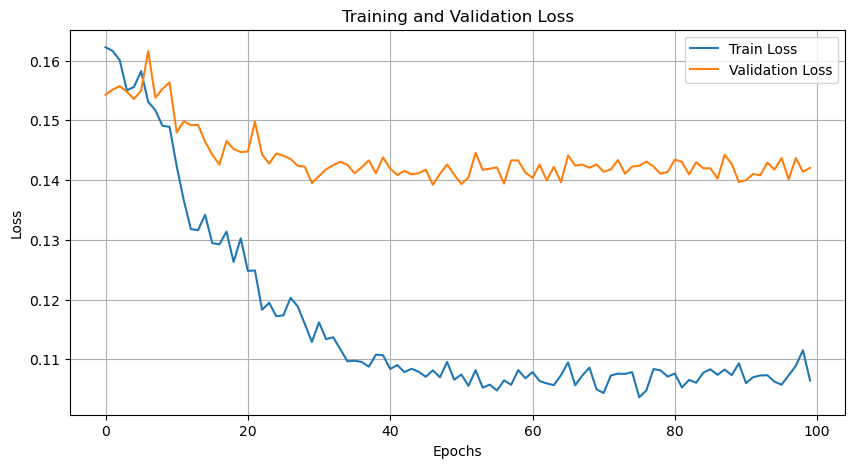

In [ ]:
plot_training(epoch_train_errors_rgb_22, epoch_val_errors_rgb_22)

In [ ]:
visualizar_test(unet_rgb_22, kaggle_loader_rgb_2, DEVICE)


In [ ]:
predict_and_build_submission(unet_rgb_22, DEVICE, kaggle_loader_rgb_2, out_csv="unet_rgb_LR_submission")

mask shape: torch.Size([8, 1, 800, 800])
batch shape: 8 range: range(0, 8)
mask shape: torch.Size([8, 1, 800, 800])
batch shape: 8 range: range(0, 8)
mask shape: torch.Size([8, 1, 800, 800])
batch shape: 8 range: range(0, 8)
mask shape: torch.Size([8, 1, 800, 800])
batch shape: 8 range: range(0, 8)
mask shape: torch.Size([8, 1, 800, 800])
batch shape: 8 range: range(0, 8)
mask shape: torch.Size([8, 1, 800, 800])
batch shape: 8 range: range(0, 8)
mask shape: torch.Size([8, 1, 800, 800])
batch shape: 8 range: range(0, 8)
mask shape: torch.Size([8, 1, 800, 800])
batch shape: 8 range: range(0, 8)
mask shape: torch.Size([8, 1, 800, 800])
batch shape: 8 range: range(0, 8)
mask shape: torch.Size([8, 1, 800, 800])
batch shape: 8 range: range(0, 8)
mask shape: torch.Size([8, 1, 800, 800])
batch shape: 8 range: range(0, 8)
mask shape: torch.Size([8, 1, 800, 800])
batch shape: 8 range: range(0, 8)
mask shape: torch.Size([8, 1, 800, 800])
batch shape: 8 range: range(0, 8)
mask shape: torch.Size([8

(           id                                     encoded_pixels
 0    1024.png  182396 5 183195 6 183994 7 184793 8 185592 9 1...
 1    1025.png  657 25 1457 25 2255 28 3053 30 3852 31 4651 32...
 2    1027.png  172496 12 172509 6 173292 26 174070 12 174087 ...
 3    1037.png  138276 9 139072 16 139869 23 140666 46 141464 ...
 4    1038.png  15165 4 15964 11 16764 14 17564 14 18365 14 19...
 ..        ...                                                ...
 529   971.png  33598 3 34397 4 35196 5 35996 5 36795 6 37595 ...
 530   975.png  589 79 1389 79 2189 79 2988 81 3787 82 4586 82...
 531   987.png  470 268 1270 268 2070 268 2870 269 3670 269 44...
 532   995.png  379 3 387 354 791 10 1179 3 1187 354 1591 10 1...
 533   999.png  213489 13 214285 21 215082 26 215878 33 216676...
 
 [534 rows x 2 columns],
 'submissions/unet_rgb_LR_submission_20-11-2025_07:56.csv')

In [ ]:
dice_post = dice_on_val_with_postproc(unet_rgb_22, val_loader_rgb_2, DEVICE, threshold=0.6) # con clean mask v2
print("Dice val con postprocesado:", dice_post = dice_on_val_with_postproc(unet_rgb_22, val_loader_rgb_2, DEVICE, threshold=0.6) # con clean mask v2
)

Dice val con postprocesado: 0.9153304689024605


In [ ]:
predict_and_build_submission(unet_rgb_22, DEVICE, kaggle_loader_rgb_2, out_csv="unet_rgb_LR_post_submission", use_post_proc=True, debug=True)

## use_upsample

### Primera prueba

In [ ]:
train_loader_up, val_loader_up, test_loader_up, kaggle_loader_up = get_seg_dataloaders(
    "data/train",
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, seed=SEED, rgb=True,
    train_transform_img=base_img_tf,
    train_transform_mask=base_mask_tf,
    val_transform_img=base_img_tf,
    val_transform_mask=base_mask_tf,  
)
unet_up = UNet(n_class=1, n_channels=3, padding=1, use_bn=True, dropout=0.3, use_upsample=True).to(DEVICE)

criterion_up = combined_loss


optimizer = torch.optim.Adam(unet_up.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=4
)

 
epoch_train_errors_up, epoch_val_errors_up = train(
    unet_up, optimizer, criterion_up, train_loader_up, val_loader_up, DEVICE, scheduler=scheduler,
    do_early_stopping=True, patience=12, epochs=200, log_every=5,
    checkpoint_path="models/unet_up_2.pth", 
    loss_ponderada=True
)

Epoch: 002 | Train Loss: 0.47124 | Val Loss: 0.56834 | Current LR: 0.0001000000
Epoch: 005 | Train Loss: 0.42298 | Val Loss: 0.41350 | Current LR: 0.0001000000
Epoch: 010 | Train Loss: 0.36971 | Val Loss: 0.32621 | Current LR: 0.0001000000
Epoch: 015 | Train Loss: 0.33330 | Val Loss: 0.28828 | Current LR: 0.0001000000
Epoch: 020 | Train Loss: 0.30751 | Val Loss: 0.26352 | Current LR: 0.0001000000
Epoch: 025 | Train Loss: 0.28817 | Val Loss: 0.23555 | Current LR: 0.0001000000
Epoch: 030 | Train Loss: 0.26325 | Val Loss: 0.22897 | Current LR: 0.0001000000
Epoch: 035 | Train Loss: 0.25202 | Val Loss: 0.21466 | Current LR: 0.0001000000
Epoch: 040 | Train Loss: 0.23766 | Val Loss: 0.20628 | Current LR: 0.0001000000
Epoch: 045 | Train Loss: 0.22135 | Val Loss: 0.18933 | Current LR: 0.0001000000
Epoch: 050 | Train Loss: 0.21044 | Val Loss: 0.18105 | Current LR: 0.0001000000
Epoch: 055 | Train Loss: 0.20550 | Val Loss: 0.17352 | Current LR: 0.0001000000
Epoch: 060 | Train Loss: 0.18916 | Val L

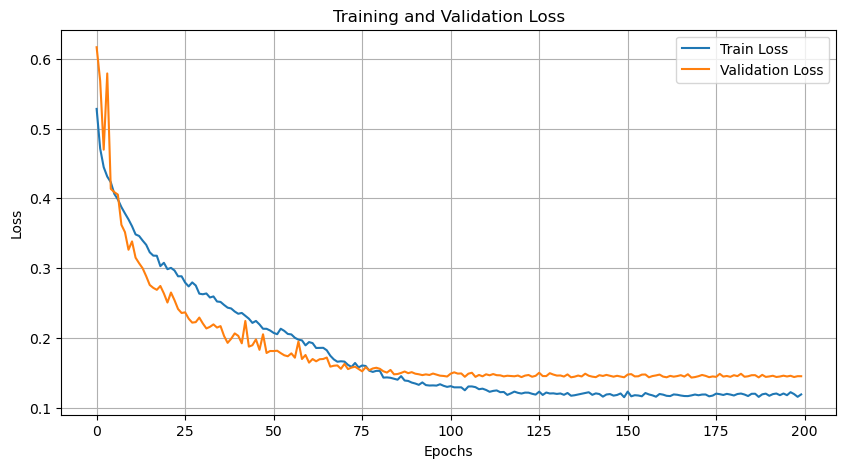

In [ ]:
plot_training(epoch_train_errors_up, epoch_val_errors_up)

Accuracy: 0.9345
Dice: 0.8978


Reporte de clasificación:

              precision      recall      f1-score     support        dice    
no-persona       0.97         0.92         0.94       8531764.0              
persona          0.89         0.95         0.92       5492940.0              
accuracy                                   0.93                              
macro avg        0.93         0.94         0.93      14024704.0       0.9    
weighted avg     0.94         0.93         0.93      14024704.0       0.9    
1                                                                     0.9    



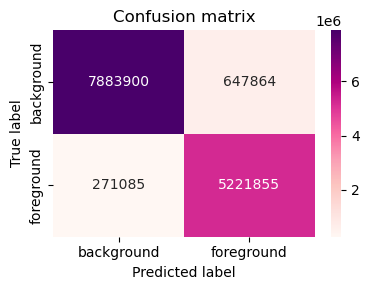

In [ ]:
acc, rep, cm = model_segmentation_report(
    unet_up, test_loader_up, DEVICE, NUM_CLASES, do_confusion_matrix=True, show_dice_loss=True
)

### Prueba 2

In [ ]:
unet_up = UNet(n_class=1, n_channels=3, padding=1, use_bn=True, dropout=0.3, use_upsample=True).to(DEVICE)
criterion_up = combined_loss


optimizer = torch.optim.Adam(unet_up.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=4
)


unet_up, _, checkpoint = restaurar_modelo(unet_up, None, "models/unet_up.pth", DEVICE)

epoch_train_errors_up, epoch_val_errors_up = train(
    unet_up, optimizer, criterion_up, train_loader_up, val_loader_up, DEVICE, scheduler=scheduler,
    do_early_stopping=False, patience=12, epochs=200, log_every=5,
    checkpoint_path="models/unet_up_2.pth",
    loss_ponderada=True
)

Epoch: 002 | Train Loss: 0.14698 | Val Loss: 0.15029 | Current LR: 0.0001000000
Epoch: 005 | Train Loss: 0.15257 | Val Loss: 0.16622 | Current LR: 0.0001000000
Epoch: 010 | Train Loss: 0.14763 | Val Loss: 0.14694 | Current LR: 0.0001000000
Epoch: 015 | Train Loss: 0.13924 | Val Loss: 0.14538 | Current LR: 0.0001000000
Epoch: 020 | Train Loss: 0.13446 | Val Loss: 0.15018 | Current LR: 0.0001000000
Epoch: 025 | Train Loss: 0.11773 | Val Loss: 0.13917 | Current LR: 0.0000500000
Epoch: 030 | Train Loss: 0.10875 | Val Loss: 0.13333 | Current LR: 0.0000500000
Epoch: 035 | Train Loss: 0.10334 | Val Loss: 0.13665 | Current LR: 0.0000250000
Epoch: 040 | Train Loss: 0.09531 | Val Loss: 0.13830 | Current LR: 0.0000125000
Epoch: 045 | Train Loss: 0.09014 | Val Loss: 0.13775 | Current LR: 0.0000062500
Epoch: 050 | Train Loss: 0.09046 | Val Loss: 0.13250 | Current LR: 0.0000062500
Epoch: 055 | Train Loss: 0.08881 | Val Loss: 0.13472 | Current LR: 0.0000031250
Epoch: 060 | Train Loss: 0.08443 | Val L

Accuracy: 0.9431
Dice: 0.9095


Reporte de clasificación:

              precision      recall      f1-score     support        dice    
no-persona       0.97         0.94         0.95       8531764.0              
persona          0.91         0.95         0.93       5492940.0              
accuracy                                   0.94                              
macro avg        0.94         0.94         0.94      14024704.0      0.91    
weighted avg     0.94         0.94         0.94      14024704.0      0.91    
1                                                                    0.91    



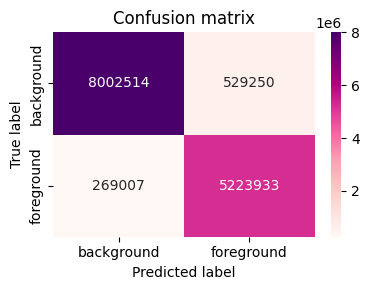

In [ ]:
acc, rep, cm = model_segmentation_report(
    unet_up, test_loader_up, DEVICE, NUM_CLASES, do_confusion_matrix=True, show_dice_loss=True
)

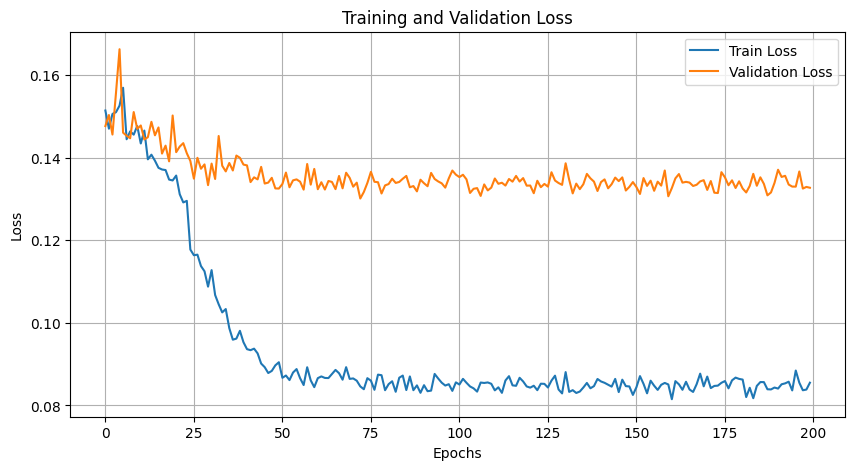

In [ ]:
plot_training(epoch_train_errors_up, epoch_val_errors_up)

In [ ]:
predict_and_build_submission(unet_up, DEVICE, kaggle_loader_up, out_csv="unet_upsample_submission", use_post_proc=True)

submission guardado como: submissions/unet_upsample_submission_23-11-2025_00:52.csv


(           id                                     encoded_pixels
 0    1024.png  250185 7 250981 12 251778 16 252576 19 253374 ...
 1    1025.png  144537 3 145324 19 146122 21 146920 24 147718 ...
 2    1027.png  179129 22 179924 30 180719 37 181509 50 182296...
 3    1037.png  139873 13 140670 19 141468 25 142266 40 143064...
 4    1038.png  31951 3 32750 6 33550 7 34349 8 35148 10 35947...
 ..        ...                                                ...
 529   971.png  117502 11 118298 18 119095 23 119893 26 120689...
 530   975.png  589 55 1388 56 2188 57 2988 57 3788 57 4587 58...
 531   987.png  473 200 1272 201 2072 201 2872 201 3672 201 44...
 532   995.png  345 200 1144 201 1944 200 2744 200 3544 194 43...
 533   999.png  214290 13 215086 21 215882 28 216679 33 217477...
 
 [534 rows x 2 columns],
 'submissions/unet_upsample_submission_23-11-2025_00:52.csv')

## Bloque con convolucion doble

In [ ]:
train_loader_dc, val_loader_dc, test_loader_dc, kaggle_loader_dc = get_seg_dataloaders(
    "data/train",
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, seed=SEED, rgb=True,
    train_transform_img=base_img_tf,
    train_transform_mask=base_mask_tf,
    val_transform_img=base_img_tf,
    val_transform_mask=base_mask_tf,  
)

unet_dc = UNet(n_class=1, n_channels=3, padding=1, use_bn=True, dropout=0.3, double_conv=True).to(DEVICE)
criterion_dc = combined_loss


optimizer = torch.optim.Adam(unet_dc.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=4
)


# model, _, checkpoint = restaurar_modelo(unet_dc, None, "models/unet_rgb_2.pth", DEVICE)
 
epoch_train_errors_rgb_22, epoch_val_errors_rgb_22 = train(
    unet_dc, optimizer, criterion_dc, train_loader_dc, val_loader_dc, DEVICE, scheduler=scheduler,
    do_early_stopping=False, patience=10, epochs=100, log_every=1,
    checkpoint_path="models/unet_dc.pth", 
    loss_ponderada=True
)

Epoch: 001 | Train Loss: 0.51231 | Val Loss: 0.49338 | Current LR: 0.0001000000
Epoch: 002 | Train Loss: 0.44785 | Val Loss: 0.41132 | Current LR: 0.0001000000
Epoch: 003 | Train Loss: 0.42270 | Val Loss: 0.41408 | Current LR: 0.0001000000
Epoch: 004 | Train Loss: 0.40040 | Val Loss: 0.41661 | Current LR: 0.0001000000
Epoch: 005 | Train Loss: 0.38305 | Val Loss: 0.36334 | Current LR: 0.0001000000
Epoch: 006 | Train Loss: 0.37119 | Val Loss: 0.38100 | Current LR: 0.0001000000
Epoch: 007 | Train Loss: 0.36060 | Val Loss: 0.32698 | Current LR: 0.0001000000
Epoch: 008 | Train Loss: 0.34438 | Val Loss: 0.32335 | Current LR: 0.0001000000
Epoch: 009 | Train Loss: 0.33525 | Val Loss: 0.30438 | Current LR: 0.0001000000
Epoch: 010 | Train Loss: 0.31802 | Val Loss: 0.27976 | Current LR: 0.0001000000
Epoch: 011 | Train Loss: 0.30969 | Val Loss: 0.29081 | Current LR: 0.0001000000
Epoch: 012 | Train Loss: 0.29827 | Val Loss: 0.25286 | Current LR: 0.0001000000
Epoch: 013 | Train Loss: 0.28682 | Val L

Accuracy: 0.9454
Dice: 0.9129


Reporte de clasificación:

              precision      recall      f1-score     support        dice    
no-persona       0.96         0.95         0.95       8531764.0              
persona          0.92         0.94         0.93       5492940.0              
accuracy                                   0.95                              
macro avg        0.94         0.95         0.94      14024704.0      0.91    
weighted avg     0.95         0.95         0.95      14024704.0      0.91    
1                                                                    0.91    



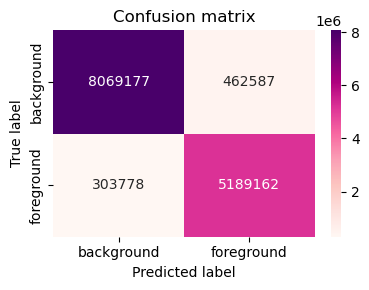

In [ ]:
acc, rep, cm = model_segmentation_report(
    unet_dc, test_loader_dc, DEVICE, NUM_CLASES, do_confusion_matrix=True, show_dice_loss=True
)

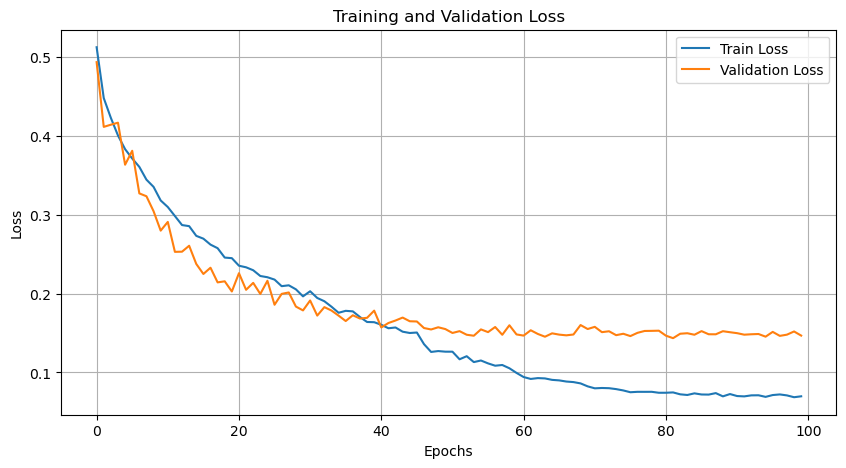

In [ ]:
plot_training(epoch_train_errors_rgb_22, epoch_val_errors_rgb_22)

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_3484/3840026845.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean = torch.tensor(mean).view(-1, 1, 1)
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_3484/3840026845.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std  = torch.tensor(std).view(-1, 1, 1)


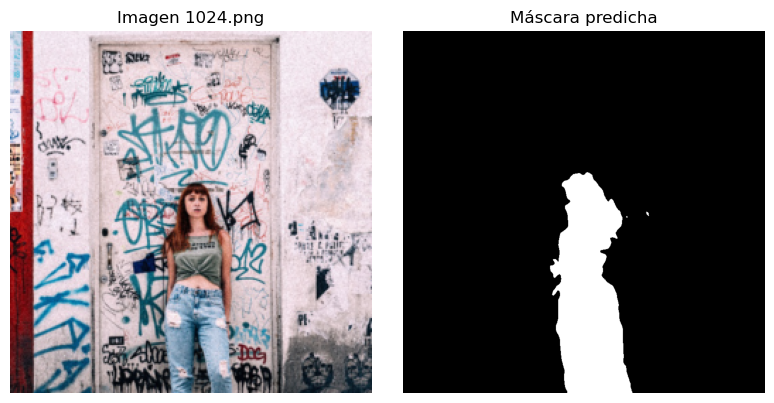

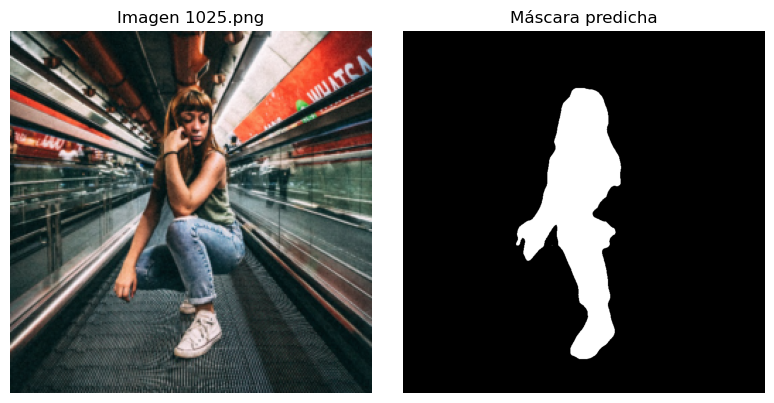

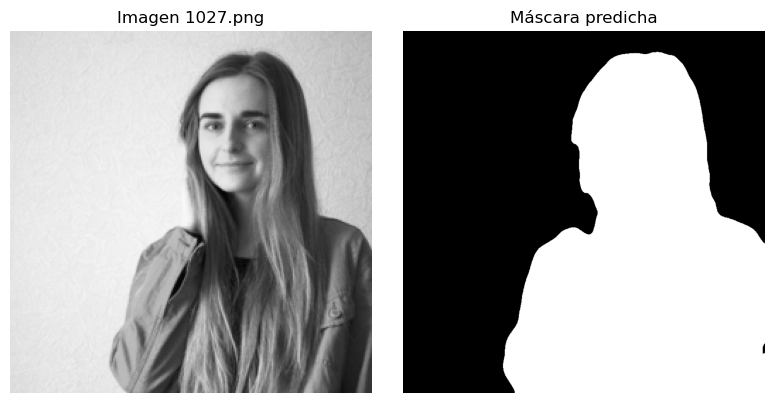

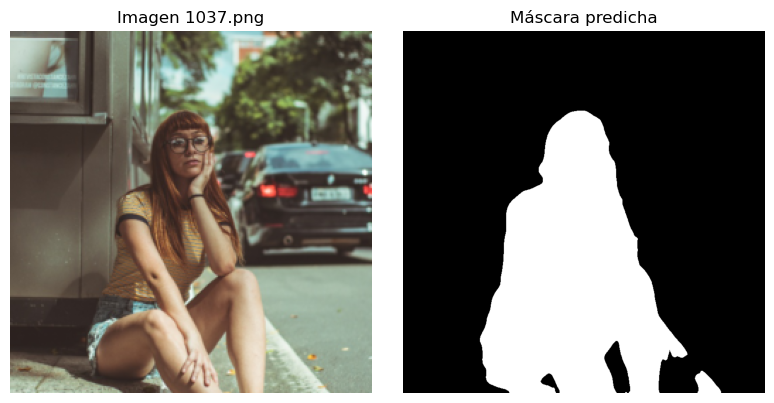

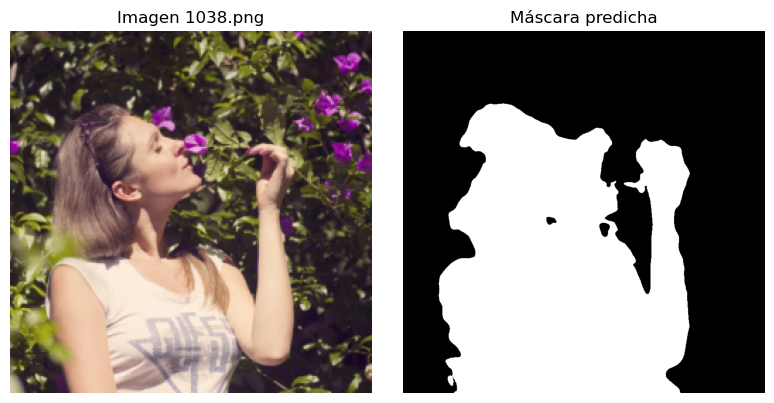

In [ ]:
visualizar_test(unet_dc, kaggle_loader_dc, DEVICE)


In [ ]:
predict_and_build_submission(unet_dc, DEVICE, kaggle_loader_dc, out_csv="unet_double_conv_submission", use_post_proc=True)

submission guardado como: submissions/unet_double_conv_submission_22-11-2025_09:33.csv


(           id                                     encoded_pixels
 0    1024.png  261321 7 262121 11 262920 13 263720 14 264519 ...
 1    1025.png  201269 4 202067 6 202847 6 202865 9 203642 14 ...
 2    1027.png  178335 11 179129 23 179924 31 180719 39 181504...
 3    1037.png  137479 9 138275 15 139073 20 139871 24 140669 ...
 4    1038.png  64557 5 64582 7 65349 47 66144 55 66942 59 677...
 ..        ...                                                ...
 529   971.png  69529 7 70329 7 71128 9 71927 10 72726 12 7352...
 530   975.png  589 62 1388 63 2188 63 2988 63 3788 62 4587 63...
 531   987.png  474 169 1273 170 2073 169 2873 170 3673 170 44...
 532   995.png  339 256 1138 257 1938 257 2738 257 3538 256 43...
 533   999.png  213492 7 214286 18 215084 22 215881 27 216679 ...
 
 [534 rows x 2 columns],
 'submissions/unet_double_conv_submission_22-11-2025_09:33.csv')

## use_upsample

In [ ]:
train_loader_up, val_loader_up, test_loader_up, kaggle_loader_up = get_seg_dataloaders(
    "data/train",
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, seed=SEED, rgb=True,
    train_transform_img=base_img_tf,
    train_transform_mask=base_mask_tf,
    val_transform_img=base_img_tf,
    val_transform_mask=base_mask_tf,
)

In [ ]:
unet_up = UNet(n_class=1, n_channels=3, padding=1, use_bn=True, dropout=0.3, use_upsample=True).to(DEVICE)
criterion_up = combined_loss


optimizer = torch.optim.Adam(unet_up.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=4
)


unet_up, _, checkpoint = restaurar_modelo(unet_up, None, "models/unet_up.pth", DEVICE)

epoch_train_errors_up, epoch_val_errors_up = train(
    unet_up, optimizer, criterion_up, train_loader_up, val_loader_up, DEVICE, scheduler=scheduler,
    do_early_stopping=False, patience=12, epochs=200, log_every=5,
    checkpoint_path="models/unet_up_2.pth",
    loss_ponderada=True
)

Epoch: 002 | Train Loss: 0.14698 | Val Loss: 0.15029 | Current LR: 0.0001000000
Epoch: 005 | Train Loss: 0.15257 | Val Loss: 0.16622 | Current LR: 0.0001000000
Epoch: 010 | Train Loss: 0.14763 | Val Loss: 0.14694 | Current LR: 0.0001000000
Epoch: 015 | Train Loss: 0.13924 | Val Loss: 0.14538 | Current LR: 0.0001000000
Epoch: 020 | Train Loss: 0.13446 | Val Loss: 0.15018 | Current LR: 0.0001000000
Epoch: 025 | Train Loss: 0.11773 | Val Loss: 0.13917 | Current LR: 0.0000500000
Epoch: 030 | Train Loss: 0.10875 | Val Loss: 0.13333 | Current LR: 0.0000500000
Epoch: 035 | Train Loss: 0.10334 | Val Loss: 0.13665 | Current LR: 0.0000250000
Epoch: 040 | Train Loss: 0.09531 | Val Loss: 0.13830 | Current LR: 0.0000125000
Epoch: 045 | Train Loss: 0.09014 | Val Loss: 0.13775 | Current LR: 0.0000062500
Epoch: 050 | Train Loss: 0.09046 | Val Loss: 0.13250 | Current LR: 0.0000062500
Epoch: 055 | Train Loss: 0.08881 | Val Loss: 0.13472 | Current LR: 0.0000031250
Epoch: 060 | Train Loss: 0.08443 | Val L

Accuracy: 0.9431
Dice: 0.9095


Reporte de clasificación:

              precision      recall      f1-score     support        dice    
no-persona       0.97         0.94         0.95       8531764.0              
persona          0.91         0.95         0.93       5492940.0              
accuracy                                   0.94                              
macro avg        0.94         0.94         0.94      14024704.0      0.91    
weighted avg     0.94         0.94         0.94      14024704.0      0.91    
1                                                                    0.91    



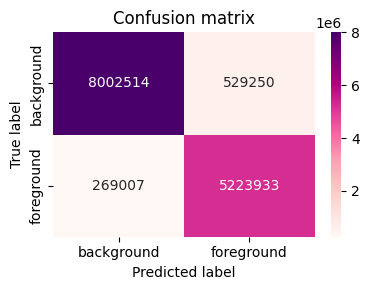

In [ ]:
acc, rep, cm = model_segmentation_report(
    unet_up, test_loader_up, DEVICE, NUM_CLASES, do_confusion_matrix=True, show_dice_loss=True
)

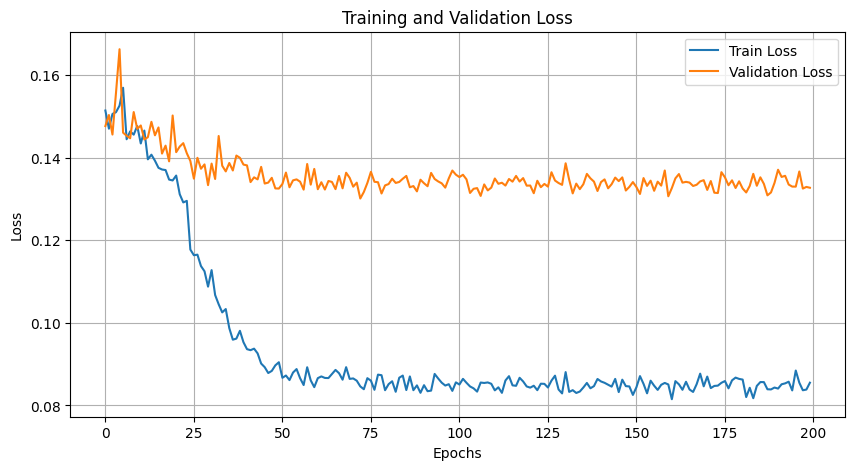

In [ ]:
plot_training(epoch_train_errors_up, epoch_val_errors_up)

In [ ]:
predict_and_build_submission(unet_up, DEVICE, kaggle_loader_up, out_csv="unet_upsample_submission", use_post_proc=True)

submission guardado como: submissions/unet_upsample_submission_23-11-2025_00:52.csv


(           id                                     encoded_pixels
 0    1024.png  250185 7 250981 12 251778 16 252576 19 253374 ...
 1    1025.png  144537 3 145324 19 146122 21 146920 24 147718 ...
 2    1027.png  179129 22 179924 30 180719 37 181509 50 182296...
 3    1037.png  139873 13 140670 19 141468 25 142266 40 143064...
 4    1038.png  31951 3 32750 6 33550 7 34349 8 35148 10 35947...
 ..        ...                                                ...
 529   971.png  117502 11 118298 18 119095 23 119893 26 120689...
 530   975.png  589 55 1388 56 2188 57 2988 57 3788 57 4587 58...
 531   987.png  473 200 1272 201 2072 201 2872 201 3672 201 44...
 532   995.png  345 200 1144 201 1944 200 2744 200 3544 194 43...
 533   999.png  214290 13 215086 21 215882 28 216679 33 217477...
 
 [534 rows x 2 columns],
 'submissions/unet_upsample_submission_23-11-2025_00:52.csv')

## Bloque con convolucion doble + UPSAMPLE

In [ ]:
train_loader_up, val_loader_up, test_loader_up, kaggle_loader_up = get_seg_dataloaders(
    "data/train",
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, seed=SEED, rgb=True,
    train_transform_img=base_img_tf,
    train_transform_mask=base_mask_tf,
    val_transform_img=base_img_tf,
    val_transform_mask=base_mask_tf,  
)

unet_up = UNet(n_class=1, n_channels=3, padding=1, use_bn=True, dropout=0.3, double_conv=True, use_upsample=True).to(DEVICE)
criterion_up = combined_loss


optimizer = torch.optim.Adam(unet_up.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=4
)


model, _, checkpoint = restaurar_modelo(unet_up, None, "models/unet_dc.pth", DEVICE)
 
epoch_train_errors_rgb_22, epoch_val_errors_rgb_22 = train(
    unet_up, optimizer, criterion_up, train_loader_up, val_loader_up, DEVICE, scheduler=scheduler,
    do_early_stopping=False, patience=10, epochs=20, log_every=5,
    checkpoint_path="models/unet_up.pth", 
    loss_ponderada=True
)

Epoch: 002 | Train Loss: 0.11176 | Val Loss: 0.14180 | Current LR: 0.0001000000
Epoch: 005 | Train Loss: 0.10696 | Val Loss: 0.16568 | Current LR: 0.0001000000
Epoch: 010 | Train Loss: 0.08677 | Val Loss: 0.14818 | Current LR: 0.0000500000
Epoch: 015 | Train Loss: 0.07226 | Val Loss: 0.15088 | Current LR: 0.0000250000
Epoch: 020 | Train Loss: 0.06197 | Val Loss: 0.15106 | Current LR: 0.0000125000


Accuracy: 0.9487
Dice: 0.9192


Reporte de clasificación:

              precision      recall      f1-score     support        dice    
no-persona       0.96         0.95         0.96       8531764.0              
persona          0.93         0.94         0.94       5492940.0              
accuracy                                   0.95                              
macro avg        0.95         0.95         0.95      14024704.0      0.92    
weighted avg     0.95         0.95         0.95      14024704.0      0.92    
1                                                                    0.92    



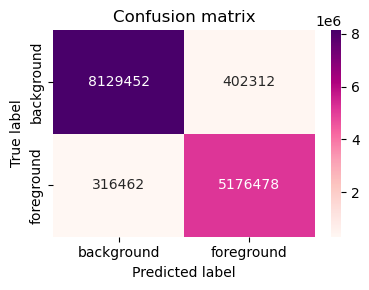

In [ ]:
acc, rep, cm = model_segmentation_report(
    unet_up, test_loader_up, DEVICE, NUM_CLASES, do_confusion_matrix=True, show_dice_loss=True
)

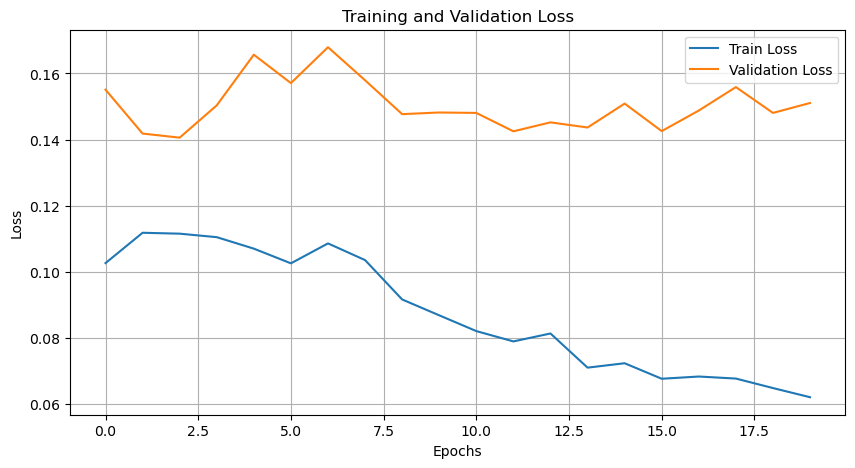

In [ ]:
plot_training(epoch_train_errors_rgb_22, epoch_val_errors_rgb_22)

In [ ]:
unet_up_post = dice_on_val_with_postproc(unet_up, val_loader_up, DEVICE, threshold=0.6) # con clean mask v2
print("Dice val con postprocesado:", unet_up_post)

Dice val con postprocesado: 0.9131129421010531


In [ ]:
predict_and_build_submission(unet_up, DEVICE, kaggle_loader_up, out_csv="unet_upsample_post_submission", use_post_proc=True)

submission guardado como: submissions/unet_upsample_post_submission_22-11-2025_11:57.csv


(           id                                     encoded_pixels
 0    1024.png  254967 7 255765 9 256563 12 257362 14 258161 1...
 1    1025.png  214886 4 215682 11 216476 19 217273 24 218070 ...
 2    1027.png  178332 14 179125 27 179920 34 180713 44 181499...
 3    1037.png  137482 5 138277 14 139074 19 139872 24 140670 ...
 4    1038.png  64584 7 65356 10 65374 21 66150 48 66947 52 67...
 ..        ...                                                ...
 529   971.png  26399 2 27197 4 27995 6 28786 15 29583 18 3038...
 530   975.png  590 54 1389 55 2189 55 2989 55 3789 56 4588 57...
 531   987.png  474 184 1273 184 2073 184 2873 183 3673 183 44...
 532   995.png  340 246 1139 247 1939 247 2739 247 3539 247 43...
 533   999.png  214288 15 215085 22 215882 27 216679 32 217477...
 
 [534 rows x 2 columns],
 'submissions/unet_upsample_post_submission_22-11-2025_11:57.csv')

## Residual Unet

In [ ]:
train_loader_res, val_loader_res, test_loader_res, kaggle_loader_res = get_seg_dataloaders(
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, seed=SEED, rgb=True,
    train_transform_img=base_img_tf,
    train_transform_mask=base_mask_tf,
    val_transform_img=base_img_tf,
    val_transform_mask=base_mask_tf,

)

unet_res = UNet(n_class=1, n_channels=3, padding=1, use_bn=True, use_res=True).to(DEVICE)
criterion_res = combined_loss_edge


optimizer = torch.optim.Adam(unet_res.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)


epoch_train_errors_res, epoch_val_errors_res = train(
    unet_res, optimizer, criterion_res, train_loader_res, test_loader_res, DEVICE, scheduler=scheduler,
    do_early_stopping=True, patience=10, epochs=100, log_every=1,
    checkpoint_path="/content/drive/MyDrive/models/unet_res.pth", loss_ponderada=False
)

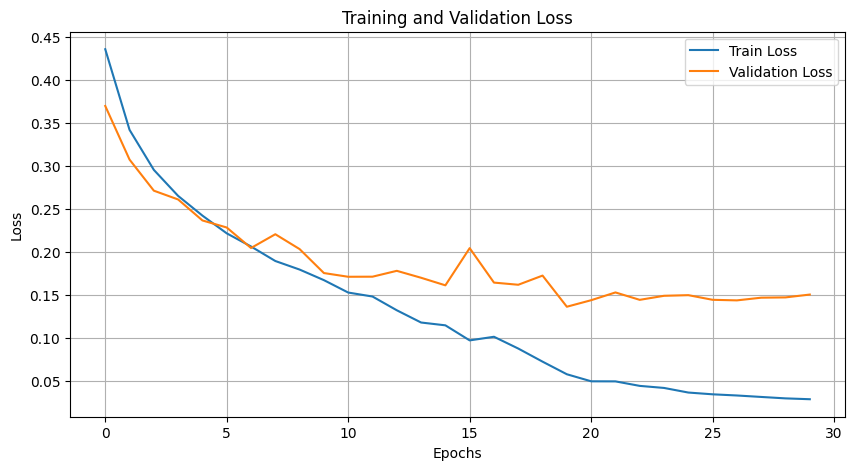

Accuracy: 0.9445
Dice: 0.9148


Reporte de clasificación:

              precision      recall      f1-score     support        dice    
no-persona       0.96         0.94         0.95       8531764.0              
persona          0.92         0.94         0.93       5492940.0              
accuracy                                   0.94                              
macro avg        0.94         0.94         0.94      14024704.0      0.91    
weighted avg     0.95         0.94         0.94      14024704.0      0.91    
1                                                                    0.91    



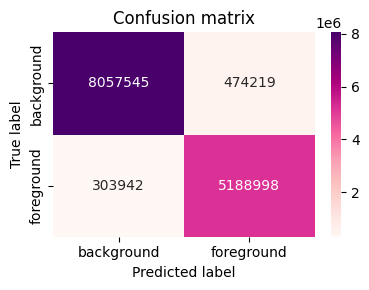

submission TTA guardado como: submissions/residual_unet_submission_27-11-2025_07:51.csv


(           id                                     encoded_pixels
 0    1024.png  262202 5 263001 7 263199 2 263800 9 263998 3 2...
 1    1025.png  82209 3 83008 4 83806 7 84605 7 85404 8 86203 ...
 2    1027.png  176731 15 177526 25 178315 40 179108 49 179902...
 3    1037.png  138303 6 139074 40 139870 54 140668 70 141464 ...
 4    1038.png  64553 7 64582 11 65346 20 65373 22 66143 53 66...
 ..        ...                                                ...
 529   971.png  41598 3 42398 3 43197 4 43997 4 44797 4 45597 ...
 530   975.png  584 59 1383 60 2183 60 2983 61 3783 61 4582 61...
 531   987.png  20553 4 21326 3 21352 7 22125 5 22150 11 22880...
 532   995.png  366190 14 366988 18 367786 23 368584 27 369382...
 533   999.png  212687 16 213484 23 214281 30 215079 35 215877...
 
 [534 rows x 2 columns],
 'submissions/residual_unet_submission_27-11-2025_07:51.csv')

In [ ]:
plot_training(epoch_train_errors_res, epoch_val_errors_res)
acc, rep, cm = model_segmentation_report(
    unet_res, test_loader_res, DEVICE, NUM_CLASES, do_confusion_matrix=True, show_dice_loss=True
)
predict_and_build_submission_tta(unet_res, DEVICE, kaggle_loader_res, out_csv="residual_unet_submission", use_post_proc=True)